# Can we predict where a currency goes next?

**Notebook 1 of 2 — direction.**

EURUSD, USDJPY and USDINR, daily data since 2015. Target: the direction of the
5-day-ahead move — up, down, or flat inside a volatility-scaled dead zone.
Every model is scored walk-forward against a named baseline.

Data is committed under `data/raw/` (Yahoo prices, FRED rates, CFTC
positioning), so this runs offline.

## 1. Data wrangling

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
RAW = Path("../data/raw")
PAIRS = {"EURUSD": "EURUSD_X", "USDJPY": "JPY_X", "USDINR": "INR_X"}

closes = {name: pd.read_parquet(RAW / f"{f}.parquet")["close"].dropna()
          for name, f in (PAIRS | {"DXY": "DX-Y_NYB", "VIX": "_VIX"}).items()}
{k: (len(v), str(v.index[0].date()), str(v.index[-1].date())) for k, v in closes.items()}

{'EURUSD': (3014, '2015-01-01', '2026-07-31'),
 'USDJPY': (3014, '2015-01-01', '2026-07-31'),
 'USDINR': (3014, '2015-01-01', '2026-07-31'),
 'DXY': (2912, '2015-01-02', '2026-07-31'),
 'VIX': (2912, '2015-01-02', '2026-07-31')}

### DXY/VIX alignment

Yahoo stamps FX daily closes earlier in the day than the US index closes. Joined
naively on date, "today's" dollar move overlaps the return being predicted. The
check: the DXY move stamped t correlates with the EURUSD return at t+1, not at t.
Both index series get a one-day lag before any join.

In [2]:
idx = closes["EURUSD"].index.intersection(closes["DXY"].index).intersection(closes["VIX"].index)
eur = np.log(closes["EURUSD"].loc[idx]).diff()
dxy = np.log(closes["DXY"].loc[idx]).diff()

print(f"corr(dxy_t, eurusd_t)   = {eur.corr(dxy):+.2f}")
print(f"corr(dxy_t, eurusd_t+1) = {eur.shift(-1).corr(dxy):+.2f}")

# Fix: lag the index series one trading day before any join.
lagged = {"DXY": closes["DXY"].shift(1), "VIX": closes["VIX"].shift(1)}

corr(dxy_t, eurusd_t)   = -0.09
corr(dxy_t, eurusd_t+1) = -0.87


In [3]:
def feature_frame(pair):
    """Daily features + the 5-day-ahead direction label for one pair."""
    px = closes[pair]
    common = px.index.intersection(closes["DXY"].index).intersection(closes["VIX"].index)
    px = px.loc[common]
    r = np.log(px).diff()

    f = pd.DataFrame(index=common)
    f["close"] = px
    f["log_return"] = r
    for w in (5, 20, 60):
        f[f"vol_{w}d"] = r.rolling(w).std()
    f["ret_z"] = (r - r.rolling(252).mean()) / r.rolling(252).std()
    f["dxy_return"] = np.log(lagged["DXY"].reindex(common)).diff()
    f["vix"] = lagged["VIX"].reindex(common)
    f["corr_dxy"] = r.rolling(60).corr(f["dxy_return"])
    f["dow"] = common.dayofweek
    f["month"] = common.month

    # Label: direction of the 5-day-ahead move, with a dead zone scaled to
    # current volatility so "flat" means "too small to matter right now".
    fwd = np.log(px).shift(-5) - np.log(px)
    dead = 0.25 * f["vol_20d"] * np.sqrt(5)
    f["label"] = np.select([fwd > dead, fwd < -dead], [2, 0], default=1).astype(float)
    f.loc[fwd.isna() | dead.isna(), "label"] = np.nan
    return f.dropna()

frames = {p: feature_frame(p) for p in PAIRS}
frames["EURUSD"].tail(3).round(4)

,close,log_return,vol_5d,vol_20d,vol_60d,ret_z,dxy_return,vix,corr_dxy,dow,month,label
date,,,,,,,,,,,,
2026-07-22,1.1404,-0.0013,0.0025,0.0027,0.0028,-0.2969,0.0019,17.05,-0.8729,2,7,0.0
2026-07-23,1.1412,0.0007,0.0011,0.0025,0.0028,0.2008,-0.0004,16.64,-0.8717,3,7,2.0
2026-07-24,1.1377,-0.0031,0.0014,0.0026,0.0028,-0.7453,0.0029,18.70,-0.8742,4,7,2.0


## 2. Data validation

In [4]:
checks = []
for pair, f in frames.items():
    gaps = f.index.to_series().diff().dt.days.max()
    checks.append({
        "pair": pair,
        "rows": len(f),
        "start": f.index[0].date(),
        "end": f.index[-1].date(),
        "max_gap_days": int(gaps),
        "dupes": int(f.index.duplicated().sum()),
        "nans": int(f.isna().sum().sum()),
        "share_up": round((f["label"] == 2).mean(), 3),
        "share_flat": round((f["label"] == 1).mean(), 3),
        "share_down": round((f["label"] == 0).mean(), 3),
    })
    assert f.index.is_monotonic_increasing and not f.index.duplicated().any()
    assert f.drop(columns="label").notna().all().all()
    assert gaps <= 14, f"{pair}: calendar gap of {gaps} days"
pd.DataFrame(checks)

,pair,rows,start,end,max_gap_days,dupes,nans,share_up,share_flat,share_down
0,EURUSD,2648,2016-01-04,2026-07-24,5,0,0,0.398,0.198,0.404
1,USDJPY,2648,2016-01-04,2026-07-24,5,0,0,0.439,0.217,0.344
2,USDINR,2648,2016-01-04,2026-07-24,5,0,0,0.414,0.259,0.327


- No duplicate dates
- No gaps beyond ordinary holidays
- No NaNs
- UP and DOWN are close to balanced.

## 3. Exploratory analysis

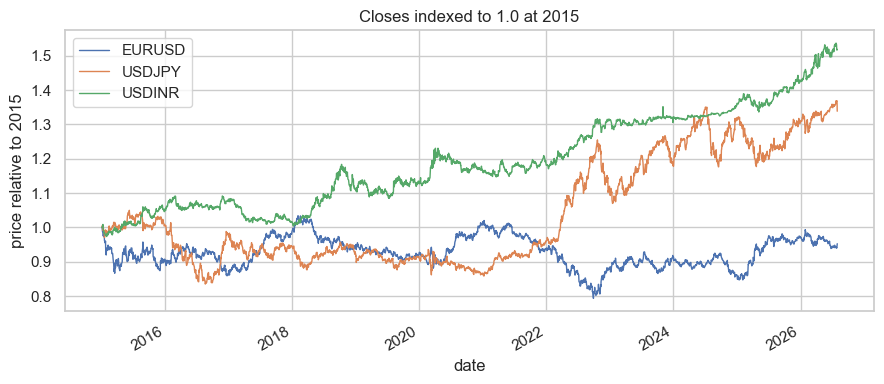

In [5]:
# Context before any modelling: the three pairs had very different decades,
# so nothing below assumes they behave alike.
norm = pd.DataFrame({p: closes[p] / closes[p].iloc[0] for p in PAIRS}).dropna()
ax = norm.plot(figsize=(9, 4), linewidth=1)
ax.set_title("Closes indexed to 1.0 at 2015")
ax.set_ylabel("price relative to 2015")
plt.tight_layout()

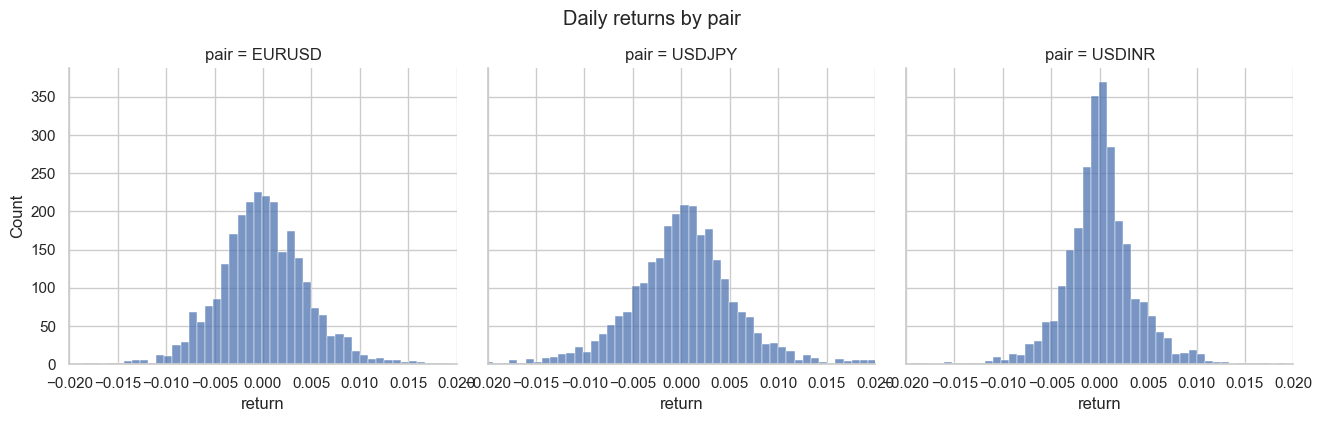

In [6]:
# The fat tails set what a "small" move is — the label's dead zone has to
# scale with them, not use a fixed threshold.
rets = pd.concat(
    [frames[p]["log_return"].rename("return").to_frame().assign(pair=p) for p in PAIRS]
)
g = sns.displot(rets, x="return", col="pair", kind="hist", bins=80,
                facet_kws={"sharex": True}, height=4, aspect=1.1)
g.set(xlim=(-0.02, 0.02))
g.figure.suptitle("Daily returns by pair", y=1.05);

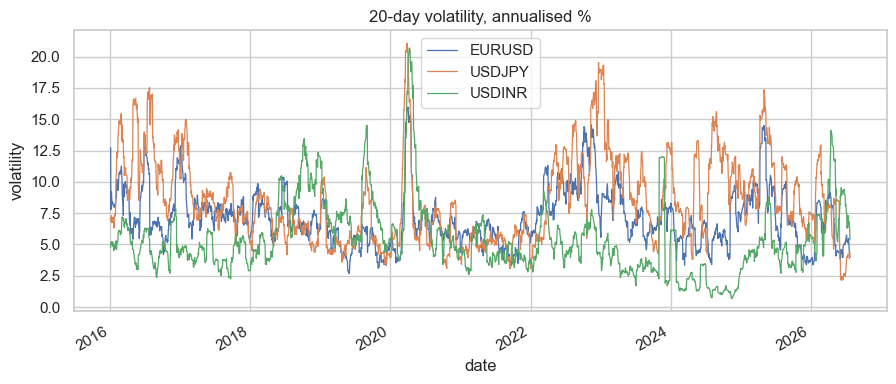

In [7]:
# Calm and stormy stretches cluster. A fixed dead zone would mislabel half
# the sample; this is also a preview of notebook 2's target.
vol = pd.DataFrame({p: frames[p]["vol_20d"] * np.sqrt(252) * 100 for p in PAIRS})
ax = vol.plot(figsize=(9, 4), linewidth=0.9)
ax.set_title("20-day volatility, annualised %")
ax.set_ylabel("volatility")
plt.tight_layout()

### Autocorrelation: returns vs |returns|

If direction has memory, returns autocorrelate. If only size has memory,
|returns| autocorrelate and returns don't.

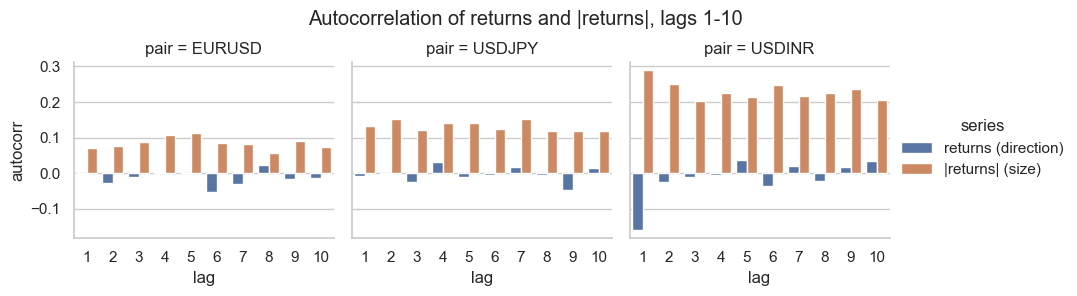

In [8]:
# The decisive check: autocorrelation of returns (direction) vs |returns|
# (size). Whatever shows memory here is what a model can hope to predict.
rows = []
for p in PAIRS:
    r = frames[p]["log_return"]
    for lag in range(1, 11):
        rows.append({"pair": p, "lag": lag, "series": "returns (direction)",
                     "autocorr": r.autocorr(lag)})
        rows.append({"pair": p, "lag": lag, "series": "|returns| (size)",
                     "autocorr": r.abs().autocorr(lag)})
ac = pd.DataFrame(rows)
g = sns.catplot(ac, x="lag", y="autocorr", hue="series", col="pair",
                kind="bar", height=2.8, aspect=1.1)
g.figure.suptitle("Autocorrelation of returns and |returns|, lags 1-10", y=1.05);

Size has memory at every lag; direction has none. That asymmetry shapes
everything below — direction models are fighting noise. Notebook 2 takes the
easier target.